In [20]:
from torchvision import datasets
import torch
data_folder = './data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, train=True, download=True)
#carrega um dataset de imagens de roupas usando a biblioteca torchvision7
# as imagens vem em tons de cinza e sao 28x28

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
train_img = fmnist.data
targets = fmnist.targets

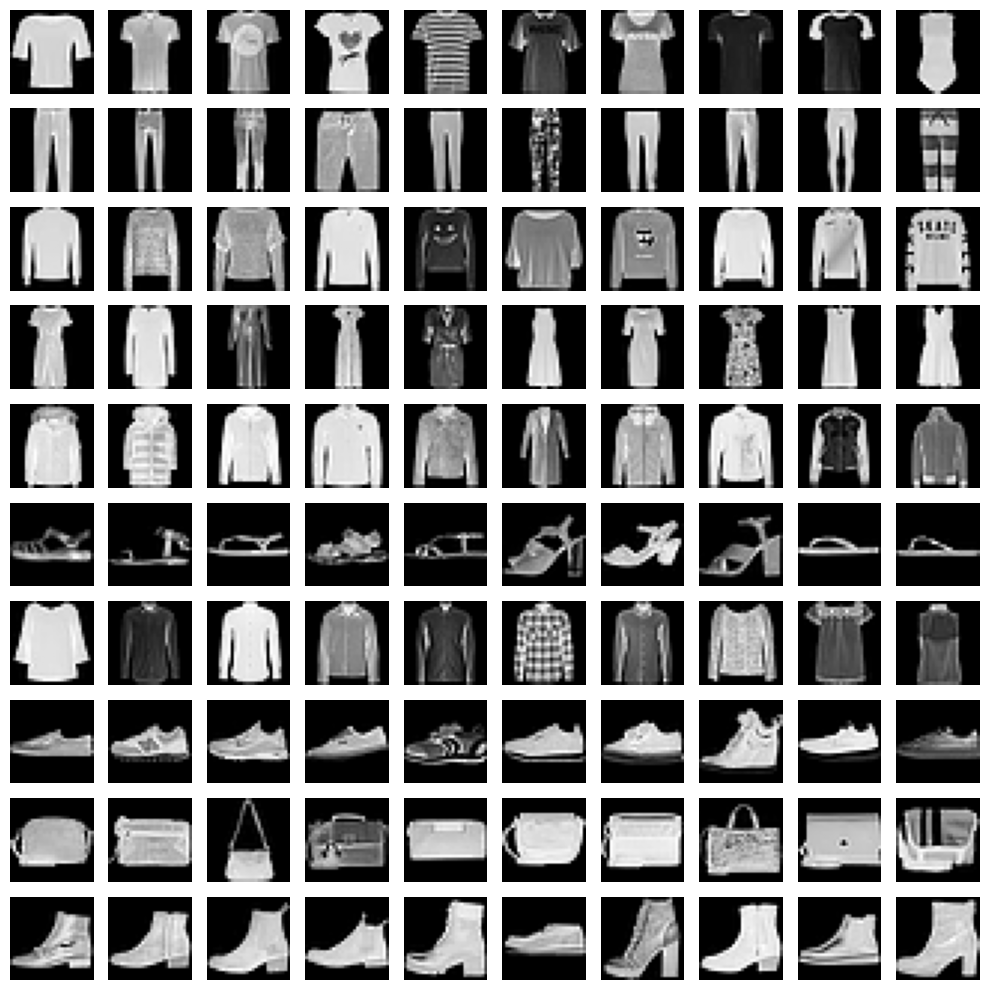

In [23]:
R, C = len(targets.unique()), 10

fig, ax = plt.subplots(R, C, figsize=(10,10))
for label_class, plot_row in enumerate(ax):
    label_x_rows = np.where(targets == label_class)[0]
    for plot_cell in plot_row:
        plot_cell.grid(False); plot_cell.axis('off')
        ix = np.random.choice(label_x_rows)
        x, y = train_img[ix], targets[ix]
        plot_cell.imshow(x, cmap='gray')
plt.tight_layout()
#esse codigo mostra 100 imagens aleatorias do dataset

In [24]:
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn


In [ ]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        # faz o flatten das imagens de 28x28 para 784
        x = x.view(-1, 28*28)
        self.x,self.y = x, y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x,y = self.x[idx], self.y[idx]

        return x, y

In [ ]:
def get_data():
    train = FMNISTDataset(train_img, targets)
    train_loader = DataLoader(train, batch_size=32, shuffle=True)
    # faz o loader com 32 imagens por batch e embaralha as imagens
    return train_loader

In [ ]:
from torch.optim import SGD
def get_model():
    # camadas da rede neural
    model = nn.Sequential(
        nn.Linear(28*28, 1000),
        # recebe todos os pixels como entradas
        nn.ReLU(),
        # funcao para eleminar valores negativos e deixar apenas positivos
        nn.Linear(1000, 10),
        # 10 saidas
        nn.ReLU(),

    )
    loss = nn.CrossEntropyLoss()
    # funcao de perda para classificacao
    optimizer = SGD(model.parameters(), lr=1e-2)
    # otimizador para atualizar os pesos da rede neural
    return model, loss, optimizer

In [ ]:
@torch.no_grad()
def accuracy(x,y,model):
    # calcula a acuracia do modelo para um batch de imagens
    model.eval()
    predict = model(x)
    max_values, max_indices = predict.max(-1)
    is_correct = max_indices == y
    return is_correct.cpu().numpy().tolist()

In [ ]:
def train_batch(x, y, model, opt, loss_fn):
    # treina o modelo para um batch de imagens
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

In [ ]:
train_loader = get_data()
model, loss_fn, opt = get_model()
# pega o model, a funcao de perda e o otimizador

In [ ]:
losses, accuracies = [], []
for epoch in range(5):
    print(epoch)
    epoch_losses, epoch_accuracies = [], []
    # treina o modelo para 5 epocas
    for ix, batch in enumerate(iter(train_loader)):
        x, y = batch
        batch_loss = train_batch(x, y, model, opt, loss_fn)
        epoch_losses.append(batch_loss)
    epoch_loss = np.array(epoch_losses).mean()
    # treina o modelo e ajusta os pesos da rede neural para cada batch de imagens

    for ix, batch in enumerate(iter(train_loader)):
        # utiliza o modelo treinado para calcular a acuracia do modelo para cada batch de imagens
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)
    epoch_accuracy = np.mean(epoch_accuracies)

    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)
    # mostra a perda e acuracia do modelo ao longo das epocas

0
1
2
3
4


/tmp/ipykernel_97859/1179357867.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


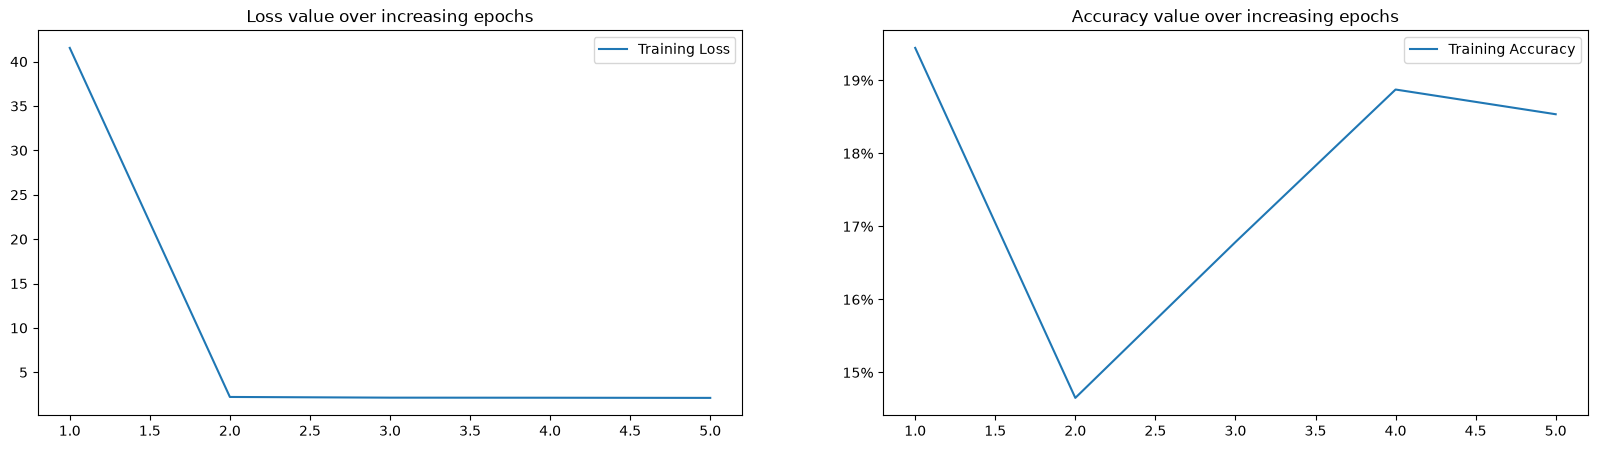

In [ ]:
epochs = np.arange(5)+1
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
# mostra graficos de perda e acuracia do modelo ao longo das epocas